In [1]:
#Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import f1_score

import joblib



import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)



In [2]:
#Datensatz laden und Inspektion

df = pd.read_csv('diabetesdata_cleaned.csv')

print(f"✅ Geladen: {df.shape[0]} Patienten, {df.shape[1]} Features")
print(f"\nErste Zeilen:")
display(df.head())

print(f"\n Datentypen:")
print(df.dtypes)

print(f"\n Fehlende Werte:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Keine fehlenden Werte! ✅")

✅ Geladen: 761 Patienten, 10 Features

Erste Zeilen:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Adipositas,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,adipositas_grade_I,0.627,50,1
1,1,85,66,29,125,26.6,praeadipositas,0.351,31,0
2,8,183,64,29,125,23.3,normalgewichtig,0.672,32,1
3,1,89,66,23,94,28.1,praeadipositas,0.167,21,0
4,0,137,40,35,168,43.1,adipositas_grade_III,2.288,33,1



 Datentypen:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
Adipositas                      str
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

 Fehlende Werte:
Keine fehlenden Werte! ✅


In [3]:
#Prüfen ob alle Spalten numerisch sind
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()

if len(non_numeric) > 0:
    print(f"WARNUNG: Nicht-numerische Spalten gefunden: {non_numeric}")
    print(f"\nDiese Spalten müssen encodiert oder entfernt werden!")
    
    # Zeige Beispielwerte
    for col in non_numeric:
        print(f"\n{col}: {df[col].unique()[:10]}")
else:
    print("✅Alle Spalten sind numerisch!")



WARNUNG: Nicht-numerische Spalten gefunden: ['Adipositas']

Diese Spalten müssen encodiert oder entfernt werden!

Adipositas: <ArrowStringArray>
[  'adipositas_grade_I',       'praeadipositas',      'normalgewichtig',
 'adipositas_grade_III',  'adipositas_grade_II',       'untergewichtig']
Length: 6, dtype: str


In [4]:
#Gefundene Spalte entfernen + erneut testen ob alle Spalten numerisch sind

df = df.drop(columns=['Adipositas']) 

non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()

if len(non_numeric) > 0:
    print(f"WARNUNG: Nicht-numerische Spalten gefunden: {non_numeric}")
    print(f"\nDiese Spalten müssen encodiert oder entfernt werden!")
    
    # Zeige Beispielwerte
    for col in non_numeric:
        print(f"\n{col}: {df[col].unique()[:10]}")
else:
    print("✅Alle Spalten sind numerisch!")



✅Alle Spalten sind numerisch!


In [5]:
# Feature und Target definieren, stratify beim Splitten aufgrund der ungleichen Verteilung

target_col = 'Outcome'

X = df.drop(target_col, axis=1)
y = df[target_col]

# Nochmal prüfen: Nur numerische Features
X = X.select_dtypes(include=[np.number])

print(f"✅ Features: {X.shape[1]} numerische Spalten")
print(f"Feature-Namen: {X.columns.tolist()}")
print(f"\n✅ Target: {target_col}")
print(f"Target-Typ: {y.dtype}")

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Training Set: {X_train.shape[0]} Samples, {X_train.shape[1]} Features")
print(f" Test Set: {X_test.shape[0]} Samples, {X_test.shape[1]} Features")

✅ Features: 8 numerische Spalten
Feature-Namen: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

✅ Target: Outcome
Target-Typ: int64

 Training Set: 608 Samples, 8 Features
 Test Set: 153 Samples, 8 Features


In [6]:
#Baseline-Model


# Baseline: Decision Tree ohne Tuning
baseline_model = DecisionTreeClassifier(max_depth=5, random_state=42)
baseline_model.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test)

# Speichern des Modells
joblib.dump(baseline_model, "baseline_model.pkl")

# Nur Accuracy
accuracy = baseline_model.score(X_test, y_test)
print(f"Baseline Accuracy: {accuracy:.3f}")

Baseline Accuracy: 0.784


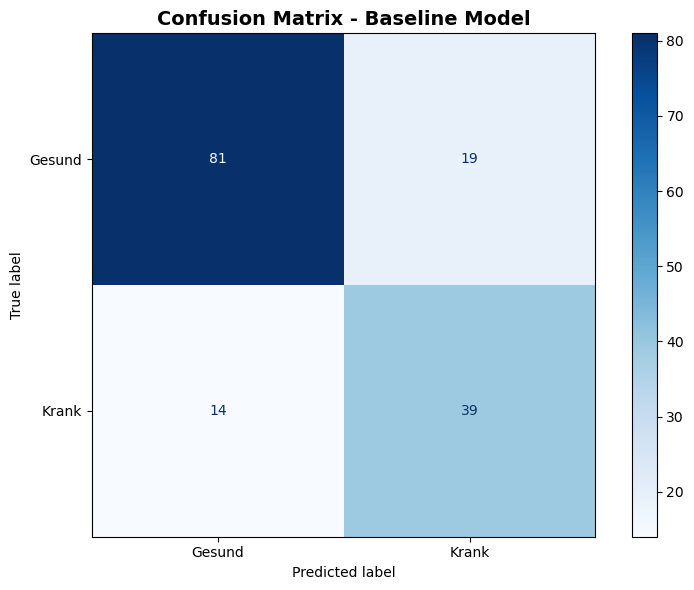


 Confusion Matrix Komponenten:
True Negatives (TN):  81 ✅ (Gesund korrekt als gesund erkannt)
False Positives (FP): 19  x (Gesund fälschlich als krank erkannt)
False Negatives (FN): 14 !! (Krank fälschlich als gesund erkannt - GEFÄHRLICH!)
True Positives (TP):  39 ✅ (Krank korrekt als krank erkannt)


In [7]:
# Confusion Matrix berechnen
cm = confusion_matrix(y_test, y_pred_baseline)

# Visualisierung
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Gesund', 'Krank']
)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Baseline Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Komponenten ausgeben
tn, fp, fn, tp = cm.ravel()
print(f"\n Confusion Matrix Komponenten:")
print(f"True Negatives (TN):  {tn} ✅ (Gesund korrekt als gesund erkannt)")
print(f"False Positives (FP): {fp}  x (Gesund fälschlich als krank erkannt)")
print(f"False Negatives (FN): {fn} !! (Krank fälschlich als gesund erkannt - GEFÄHRLICH!)")
print(f"True Positives (TP):  {tp} ✅ (Krank korrekt als krank erkannt)")

 5-Fold Cross-Validation Results (Baseline Model):
ACCURACY    : 0.736 (+/- 0.046)
             Individual scores: ['0.732', '0.651', '0.776', '0.776', '0.743']
PRECISION   : 0.636 (+/- 0.070)
             Individual scores: ['0.650', '0.500', '0.694', '0.686', '0.652']
RECALL      : 0.608 (+/- 0.070)
             Individual scores: ['0.491', '0.679', '0.642', '0.660', '0.566']
F1          : 0.616 (+/- 0.046)
             Individual scores: ['0.559', '0.576', '0.667', '0.673', '0.606']
ROC_AUC     : 0.775 (+/- 0.030)
             Individual scores: ['0.773', '0.741', '0.816', '0.800', '0.743']


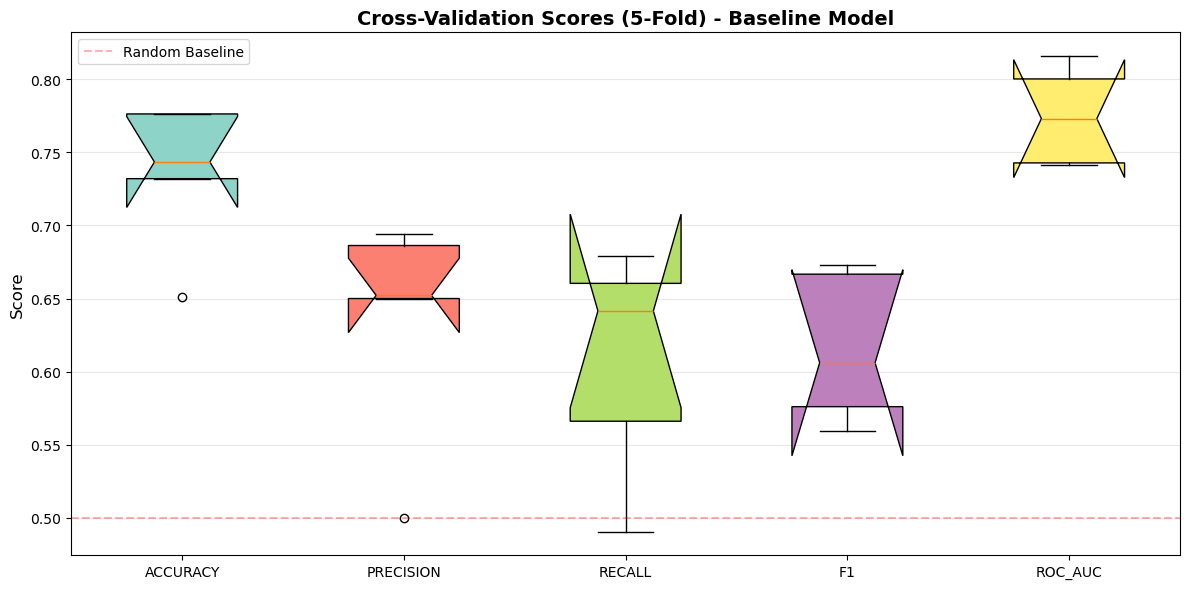

In [8]:
#Cross-Validation
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print(" 5-Fold Cross-Validation Results (Baseline Model):")
print("="*70)

cv_results = {}
for metric in metrics:
    scores = cross_val_score(
        baseline_model, X, y, cv=5, scoring=metric
    )
    cv_results[metric] = scores
    print(f"{metric.upper():12s}: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"             Individual scores: {[f'{s:.3f}' for s in scores]}")


# Visualisierung der CV Scores
fig, ax = plt.subplots(figsize=(12, 6))

positions = np.arange(len(metrics))
bp = ax.boxplot([cv_results[m] for m in metrics], 
                 positions=positions,
                 labels=[m.upper() for m in metrics],
                 patch_artist=True,
                 notch=True)

# Farben
colors = plt.cm.Set3(np.linspace(0, 1, len(metrics)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Cross-Validation Scores (5-Fold) - Baseline Model', 
            fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.3, label='Random Baseline')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
#Feature Engineering im Bezug auf fehlende Werte (Insulin und SkinThickness), Risk Score Feature und Interaction Features
X_engineered = X.copy()


X_engineered['Insulin_Missing'] = (df['Insulin'] == 125).astype(int)
X_engineered['SkinThickness_Missing'] = (df['SkinThickness'] == 29).astype(int)

X_engineered['RiskScore'] = (
    (df['Glucose'] >= 140).astype(int) +                        
    (df['BMI'] >= 30).astype(int) +                              
    (df['Age'] >= 40).astype(int) +                              
    (df['BloodPressure'] >= 80).astype(int)                    
  
)

X_engineered['Glucose_x_Age'] = X_engineered['Glucose'] * X_engineered['Age']
X_engineered['Glucose_x_BMI'] = X_engineered['Glucose'] * X_engineered['BMI']
X_engineered['BMI_x_Age']     = X_engineered['BMI'] * X_engineered['Age']


print(f"\n Feature Summary:")
print(f"Original Features: {X.shape[1]}")
print(f"Neue Features erstellt: {X_engineered.shape[1] - X.shape[1]}")
print(f"Gesamt Features: {X_engineered.shape[1]}")

print(f"\n Alle neuen Features:")
new_features = [col for col in X_engineered.columns if col not in X.columns]
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")


 Feature Summary:
Original Features: 8
Neue Features erstellt: 6
Gesamt Features: 14

 Alle neuen Features:
  1. Insulin_Missing
  2. SkinThickness_Missing
  3. RiskScore
  4. Glucose_x_Age
  5. Glucose_x_BMI
  6. BMI_x_Age


In [10]:
# Train/Test Split mit neuen Features
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42, stratify=y
)

# Modell mit neuen Features trainieren
model_engineered = DecisionTreeClassifier(max_depth=5, random_state=42)
model_engineered.fit(X_train_eng, y_train_eng)

# Evaluation
y_pred_eng = model_engineered.predict(X_test_eng)
print(f"\n Vergleich: Original vs. Feature Engineering")
print("="*60)
print(f"Baseline Accuracy:  {baseline_model.score(X_test, y_test):.3f}")
print(f"Engineered Accuracy: {model_engineered.score(X_test_eng, y_test_eng):.3f}")

# F1-Score Vergleich
f1_baseline = f1_score(y_test, y_pred_baseline)
f1_eng = f1_score(y_test_eng, y_pred_eng)
print(f"\nBaseline F1-Score:  {f1_baseline:.3f}")
print(f"Engineered F1-Score: {f1_eng:.3f}")
print(f"\n{'✅ Verbesserung!' if f1_eng > f1_baseline else '❌ Verschlechterung'}" if f1_eng != f1_baseline else '📊 Gleichbleibend')



 Vergleich: Original vs. Feature Engineering
Baseline Accuracy:  0.784
Engineered Accuracy: 0.752

Baseline F1-Score:  0.703
Engineered F1-Score: 0.525

❌ Verschlechterung


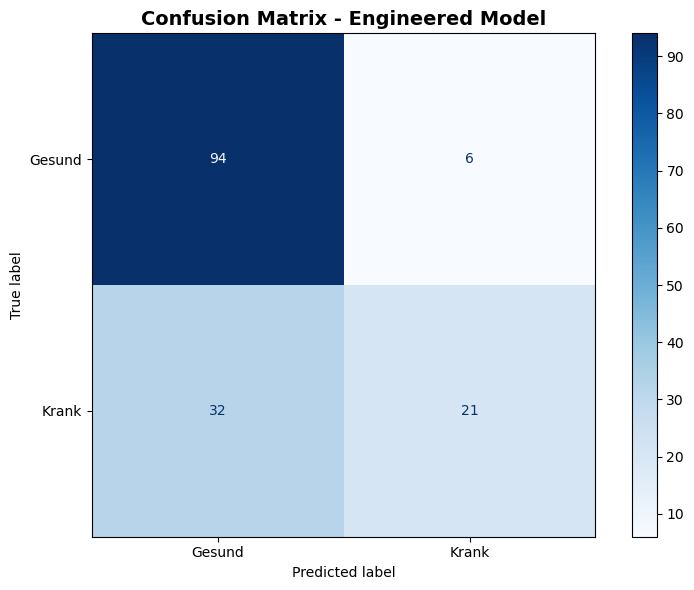

In [11]:
# Confusion Matrix berechnen
cm = confusion_matrix(y_test_eng, y_pred_eng)

# Visualisierung
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Gesund', 'Krank']
)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Engineered Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Parameter-Grid für Decision Tree
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV mit F1-Score als Metrikauf dem Standard-80/20-Split des Baseline-Modell
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Starte GridSearchCV...")
print(f"Anzahl Kombinationen: {len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['criterion'])}")
print(f"Mit 5-Fold CV: {5 * 5 * 4 * 4 * 2} Modelle werden trainiert!")

grid_search.fit(X_train, y_train)

# Beste Parameter
print(" Beste Parameter:")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"{param:20s}: {value}")

print(f" Beste CV F1-Score: {grid_search.best_score_:.3f}")

# Top 10 Konfigurationen
results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score').head(10)

print(" Top 10 Parameter-Kombinationen:")
print("="*80)
display(top_results)

# Bestes Modell evaluieren auf Test-Set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(" Vergleich: Baseline (ungetunt) vs. GridSearch-Optimiert")
print("="*70)
print(f"Baseline, ungetunt (max_depth=5):")
print(f"  Test Accuracy:  {baseline_model.score(X_test, y_test):.3f}")
print(f"  Test F1-Score:  {f1_score(y_test, y_pred_baseline):.3f}")

print(f"Optimiert (GridSearch):")
print(f"  Test Accuracy:  {best_model.score(X_test, y_test):.3f}")
print(f"  Test F1-Score:  {f1_score(y_test, y_pred_best):.3f}")

Starte GridSearchCV...
Anzahl Kombinationen: 160
Mit 5-Fold CV: 800 Modelle werden trainiert!
Fitting 5 folds for each of 160 candidates, totalling 800 fits
 Beste Parameter:
criterion           : entropy
max_depth           : 7
min_samples_leaf    : 8
min_samples_split   : 2
 Beste CV F1-Score: 0.627
 Top 10 Parameter-Kombinationen:


,params,mean_test_score,std_test_score,rank_test_score
126,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.627481,0.072556,1
124,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.627481,0.072556,1
125,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.627481,0.072556,1
127,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.623464,0.076454,4
140,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.622484,0.053508,5
141,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.622484,0.053508,5
142,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.622484,0.053508,5
158,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.621590,0.046794,8
157,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.621590,0.046794,8
156,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.621590,0.046794,8


 Vergleich: Baseline (ungetunt) vs. GridSearch-Optimiert
Baseline, ungetunt (max_depth=5):
  Test Accuracy:  0.784
  Test F1-Score:  0.703
Optimiert (GridSearch):
  Test Accuracy:  0.771
  Test F1-Score:  0.696


In [13]:
#Parameter Grid für Random Forest Tuning



# Parameter-Grid für Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV mit F1-Score als Metrik
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("🔍 Starte GridSearchCV für Random Forest...")
print(f"Anzahl Kombinationen: {len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_split'])}")
print(f"Mit 5-Fold CV: {5 * 3 * 3 * 3} Modelle werden trainiert!\n")

grid_search_rf.fit(X_train, y_train)

# Beste Parameter
print(" Beste Parameter (Random Forest):")
print("="*60)
for param, value in grid_search_rf.best_params_.items():
    print(f"{param:20s}: {value}")

print(f"\n Beste CV F1-Score: {grid_search_rf.best_score_:.3f}")

# Bestes Modell evaluieren auf Test-Set
best_model_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_model_rf.predict(X_test)

print("\n Vergleich: Vergleich: Baseline (ungetunt) vs. GridSearch Random Forest")
print("="*70)
print(f"Baseline (ungetunt)")
print(f"  Test Accuracy:  {baseline_model.score(X_test, y_test):.3f}")
print(f"  Test F1-Score:  {f1_score(y_test, y_pred_baseline):.3f}")


print(f"\nGridSearch Random Forest (getunt):")
print(f"  Test Accuracy:  {best_model_rf.score(X_test, y_test):.3f}")
print(f"  Test F1-Score:  {f1_score(y_test, y_pred_best_rf):.3f}")

🔍 Starte GridSearchCV für Random Forest...
Anzahl Kombinationen: 27
Mit 5-Fold CV: 135 Modelle werden trainiert!

Fitting 5 folds for each of 27 candidates, totalling 135 fits
 Beste Parameter (Random Forest):
max_depth           : 10
min_samples_split   : 10
n_estimators        : 50

 Beste CV F1-Score: 0.671

 Vergleich: Vergleich: Baseline (ungetunt) vs. GridSearch Random Forest
Baseline (ungetunt)
  Test Accuracy:  0.784
  Test F1-Score:  0.703

GridSearch Random Forest (getunt):
  Test Accuracy:  0.752
  Test F1-Score:  0.604


🔧 Starte Pipeline GridSearch...

Fitting 5 folds for each of 48 candidates, totalling 240 fits
 Beste Pipeline-Parameter:
classifier__max_depth              : 7
classifier__min_samples_split      : 5
selector__k                        : 8

 Beste CV F1-Score: 0.604

 Ausgewählte Features (Top 8):
  1. Pregnancies
  2. Glucose
  3. BloodPressure
  4. SkinThickness
  5. Insulin
  6. BMI
  7. DiabetesPedigreeFunction
  8. Age

 FINALER MODELL-VERGLEICH


,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline,0.784,0.672,0.736,0.703
1,Feature Engineering,0.752,0.778,0.396,0.525
2,GridSearch Optimiert,0.771,0.645,0.755,0.696
3,GridSearchCV Random Forest,0.752,0.674,0.547,0.604
4,Pipeline (Best),0.765,0.649,0.698,0.673


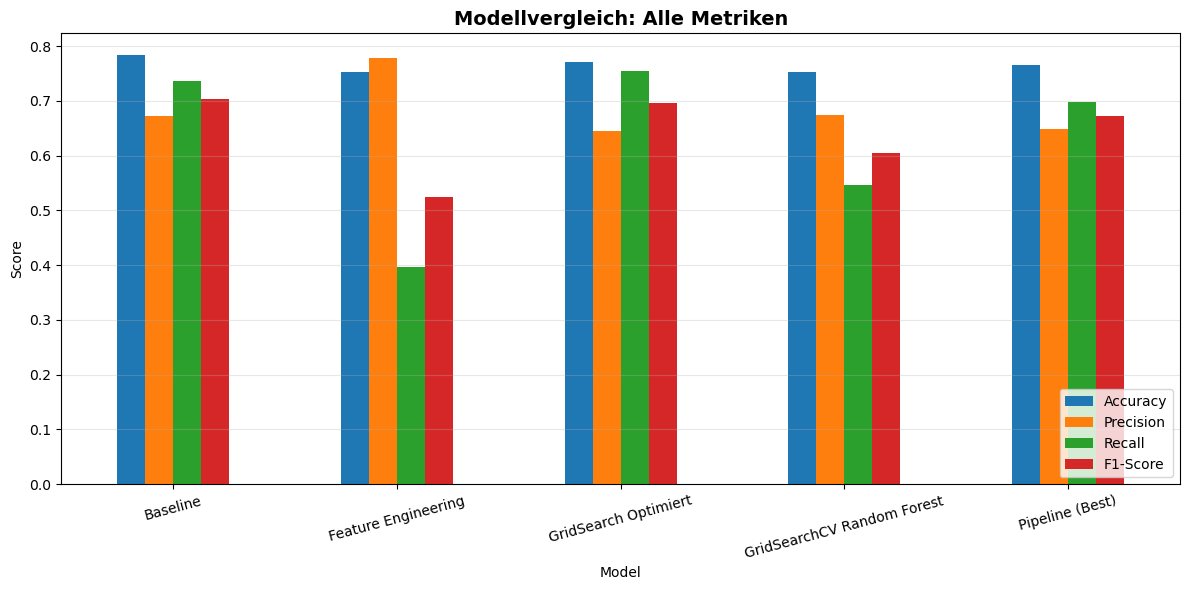

In [14]:
#Pipeline

# Pipeline erstellen
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif, k=10)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Parameter-Grid für Pipeline
param_grid_pipeline = {
    'selector__k': [3, 5, 6, 8],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10]
}

# GridSearch auf Pipeline
grid_search_pipeline = GridSearchCV(
    pipeline,
    param_grid_pipeline,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("🔧 Starte Pipeline GridSearch...\n")
grid_search_pipeline.fit(X_train, y_train)


# Beste Pipeline-Parameter
print(" Beste Pipeline-Parameter:")
print("="*60)
for param, value in grid_search_pipeline.best_params_.items():
    print(f"{param:35s}: {value}")

print(f"\n Beste CV F1-Score: {grid_search_pipeline.best_score_:.3f}")

# Welche Features wurden ausgewählt?
best_pipeline = grid_search_pipeline.best_estimator_
selector = best_pipeline.named_steps['selector']
selected_features = X_train.columns[selector.get_support()]

print(f"\n Ausgewählte Features (Top {len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")


# Finale Evaluation auf Test-Set
y_pred_pipeline = best_pipeline.predict(X_test)

print("\n" + "="*70)
print(" FINALER MODELL-VERGLEICH")
print("="*70)

models_comparison = {
    'Baseline': (baseline_model, X_test, y_test, y_pred_baseline),
    'Feature Engineering': (model_engineered, X_test_eng, y_test_eng, y_pred_eng),
    'GridSearch Optimiert': (best_model, X_test, y_test, y_pred_best),
    'GridSearchCV Random Forest': (best_model_rf, X_test, y_test, y_pred_best_rf),
    'Pipeline (Best)': (best_pipeline, X_test, y_test, y_pred_pipeline)
}

comparison_results = []
for name, (model, X_t, y_t, y_p) in models_comparison.items():
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    comparison_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_t, y_p),
        'Precision': precision_score(y_t, y_p),
        'Recall': recall_score(y_t, y_p),
        'F1-Score': f1_score(y_t, y_p)
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.round(3)
display(comparison_df)

# Visualisierung
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=ax, rot=15
)
ax.set_ylabel('Score')
ax.set_title('Modellvergleich: Alle Metriken', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()